In [50]:
import joblib
import numpy as np
import pandas as pd
import xgboost as xgb
import missingno as msno
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, GRU
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [51]:
path = "../last_dataset.csv"
df = pd.read_csv(path)
df.head()

,GLD,Date,USO_prev,SLV_prev,EURUSD=X_prev,^GSPC_prev,sentiment_prev
0,102.269997,2015-12-28,NaN,NaN,NaN,NaN,NaN
1,102.199997,2015-12-29,87.440002,13.29,1.096599,2056.500000,positive
2,101.419998,2015-12-30,90.080002,13.27,1.097526,2078.360107,positive
3,101.459999,2015-12-31,87.440002,13.21,1.092801,2063.360107,positive
4,102.889999,2016-01-04,88.000000,13.19,1.093398,2043.939941,positive


In [52]:
df = df[df["Date"] >= "2023-01-01"]

In [53]:
df = df.dropna()

In [54]:
sentiment_map = {"positive": 1, "neutral": 0, "negative": -1}
df["sentiment"] = df["sentiment_prev"].map(sentiment_map)
df.head()

,GLD,Date,USO_prev,SLV_prev,EURUSD=X_prev,^GSPC_prev,sentiment_prev,sentiment
1762,171.059998,2023-01-03,70.110001,22.020000,1.066075,3839.500000,positive,1
1763,172.669998,2023-01-04,67.639999,22.049999,1.067771,3824.139893,positive,1
1764,170.520004,2023-01-05,64.300003,21.889999,1.054685,3852.969971,positive,1
1765,173.710007,2023-01-06,64.779999,21.389999,1.060637,3808.100098,positive,1
1766,174.100006,2023-01-09,64.830002,21.920000,1.052222,3895.080078,positive,1


In [55]:
df = df.drop(columns=["sentiment_prev"])

**1. LSTM model**

In [56]:
def create_sequences(df_seq, features, target_col, n_steps, scaler_X, scaler_y):
    data_scaled = df_seq.copy()
    X_scaled = scaler_X.transform(data_scaled[features])
    y_scaled = scaler_y.transform(data_scaled[[target_col]])

    X_seq, y_seq = [], []
    for i in range(n_steps, len(data_scaled)):
        X_seq.append(X_scaled[i - n_steps:i])
        y_seq.append(y_scaled[i])
    return np.array(X_seq), np.array(y_seq)

In [57]:
features = ['USO_prev', 'SLV_prev', 'EURUSD=X_prev', '^GSPC_prev', 'sentiment']
target = 'GLD'

split_index = int(len(df) * 0.8)
train_df, test_df = df.iloc[:split_index], df.iloc[split_index:]

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

scaler_X.fit(train_df[features])
scaler_y.fit(train_df[[target]])

n_steps = 10
X_lstm_train, y_lstm_train = create_sequences(train_df, features, target, n_steps, scaler_X, scaler_y)
X_lstm_test, y_lstm_test   = create_sequences(test_df, features, target, n_steps, scaler_X, scaler_y)

x_axis = test_df.index[n_steps:] 


# model_lstm = Sequential([
#     GRU(128, return_sequences=True, input_shape=(n_steps, len(features))),
#     Dropout(0.3),
#     GRU(64),
#     Dropout(0.3),
#     Dense(1)
# ])
model_lstm = joblib.load("../best_lstm.pkl")
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_lstm_train, y_lstm_train, epochs=20, batch_size=16, verbose=0)

lstm_preds = model_lstm.predict(X_lstm_test).ravel()


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


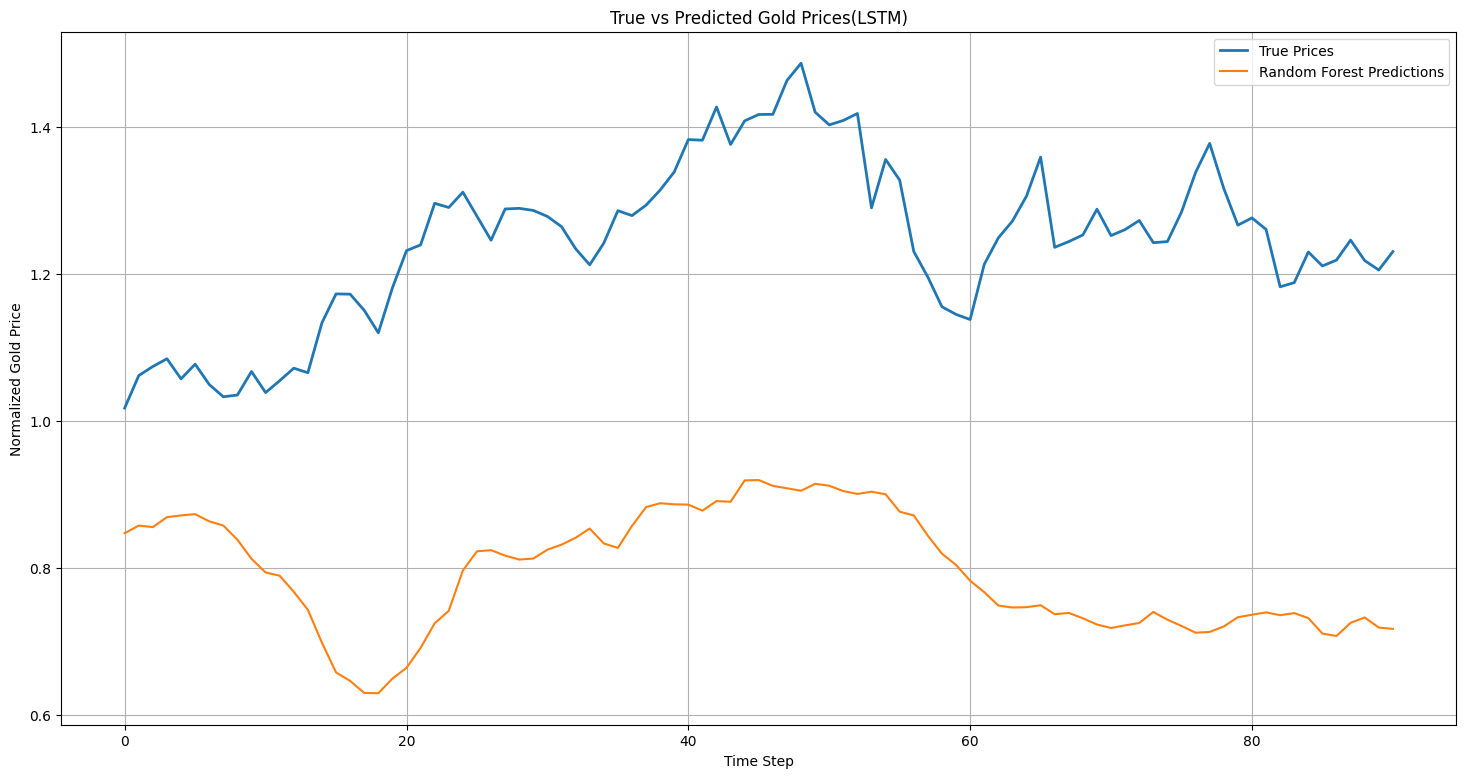

In [58]:
plt.figure(figsize=(18, 9))
plt.plot(y_lstm_test, label='True Prices', linewidth=2)
plt.plot(lstm_preds, label='Random Forest Predictions')
plt.title('True vs Predicted Gold Prices(LSTM)')
plt.xlabel('Time Step')
plt.ylabel('Normalized Gold Price')
plt.legend()
plt.grid(True)
plt.show()

**Meta model**

In [59]:
meta_df = pd.DataFrame({
    "lstm_preds": lstm_preds,
    "y_true": y_lstm_test.ravel()
})

In [60]:
meta_df.head()

,lstm_preds,y_true
0,0.847700,1.018018
1,0.858033,1.062229
2,0.855973,1.074575
3,0.869493,1.085085
4,0.871871,1.057725


In [61]:
meta_df.isnull().sum()

lstm_preds    0
y_true        0
dtype: int64

In [62]:
len(meta_df)

91

In [63]:
X = meta_df[["lstm_preds"]]   
y = meta_df["y_true"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  
)

In [66]:
meta_model= RandomForestRegressor(n_estimators=100, random_state=42)
meta_model.fit(X_train, y_train.ravel())
rf_preds = meta_model.predict(X_test)

meta_model.fit(X_train, y_train)

C:\Users\User\AppData\Local\Temp\ipykernel_3204\2203127502.py:2: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  meta_model.fit(X_train, y_train.ravel())


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


  Metric     Value
0    MSE  0.002253
1     R²  0.066083
2    MAE  0.040087


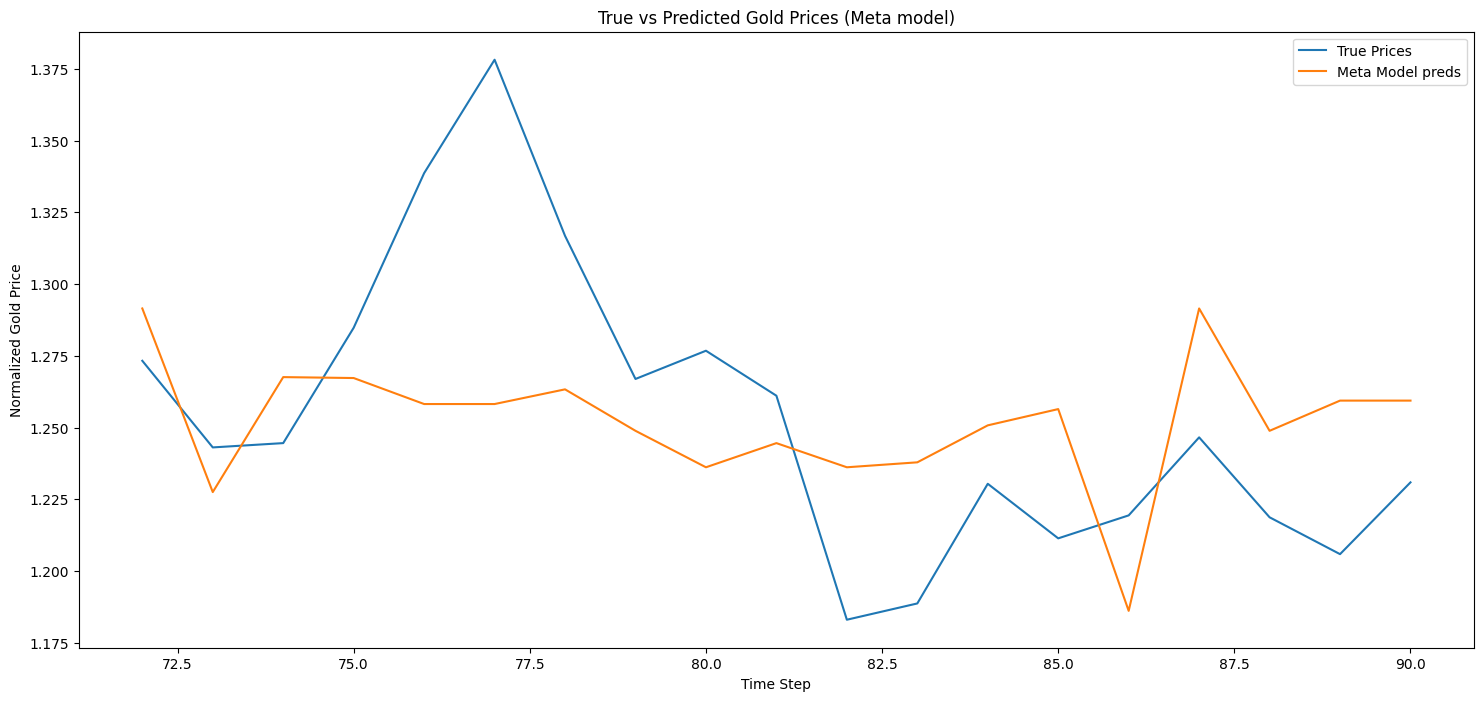

In [67]:
meta_preds = meta_model.predict(X_test)

mse = mean_squared_error(y_test, meta_preds)
r2 = r2_score(y_test, meta_preds)
mae = mean_absolute_error(y_test, meta_preds)

results_df = pd.DataFrame({
    "Metric": ["MSE", "R²", "MAE"],
    "Value": [mse, r2, mae]
})
print(results_df)

plt.figure(figsize=(18, 8))
plt.plot(y_test.index, y_test, label="True Prices")
plt.plot(y_test.index, meta_preds, label="Meta Model preds")
plt.xlabel("Time Step")
plt.ylabel("Normalized Gold Price")
plt.title("True vs Predicted Gold Prices (Meta model)")
plt.legend()
plt.show()


In [71]:
joblib.dump(meta_model, "../best_meta.pkl")

['../best_meta.pkl']

**Prediction of the next month**

In [70]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Assume df has columns ['Date', 'Price']
df = df.sort_values('Date')
prices = df['GLD'].values.reshape(-1, 1)

# Scale prices
scaler = MinMaxScaler()
prices_scaled = scaler.fit_transform(prices)

# Function to create LSTM sequences
def create_sequences(data, seq_length=30):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 30  # past 30 days
X, y = create_sequences(prices_scaled, seq_length)

# Train LSTM
lstm_model = Sequential([
    LSTM(50, activation='relu', input_shape=(seq_length, 1)),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X, y, epochs=50, batch_size=16, verbose=0)

# LSTM predictions
lstm_preds = lstm_model.predict(X)

# Meta-model (Random Forest)
meta_df = pd.DataFrame({
    'lstm_pred': lstm_preds.flatten(),
    'y_true': y.flatten()
})
meta_df['lag_price'] = prices_scaled[seq_length-1:-1,0]  # previous real price

X_meta = meta_df[['lstm_pred', 'lag_price']]
y_meta = meta_df['y_true']

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_meta, y_meta)

# ---- Forecast next month ----
future_preds = []
current_seq = prices_scaled[-seq_length:]  # last 30 days

for _ in range(30):  # predict next 30 days
    lstm_pred = lstm_model.predict(current_seq.reshape(1, seq_length, 1))[0,0]
    meta_input = np.array([[lstm_pred, current_seq[-1,0]]])
    adj_pred = rf.predict(meta_input)[0]
    future_preds.append(adj_pred)
    
    # Update sequence for next day
    current_seq = np.vstack([current_seq[1:], [[adj_pred]]])

# Inverse transform
future_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1,1))
print(future_preds)


c:\Users\User\dev\training_model\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
[[240.84175354]
 [241.56845459]
 [241.60400505]
 [241.52705513]
 [241.59290504]
 [241.26175507]
 [241.45000519]
 [241.47960548]
 [241.53220558]
 [241.46620544]
 [241.85300575]
 [241.07965416]
 [241.96690529]
 [241.12985413]
 [241.97365524]
 [241.12985413]
 [241.99895523]
 [241.12985413]
 [242.23845535]
 [241.26845253]
 [241.83290573]
 [241.11610428]
 [242.24270538]
 [241.26845253]
 [241.83290573]
 [241.11610428]
 [242.24660538]
 [241.26845253]
 [241.83290573]
 [241.11610428]]


c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


c:\Users\User\dev\training_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


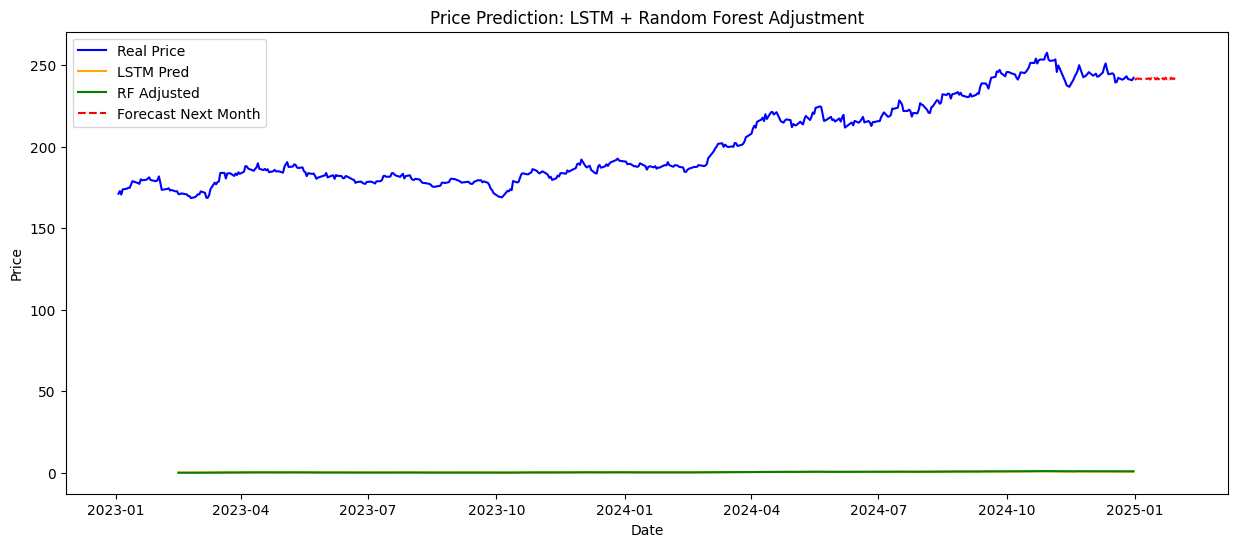

In [76]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df['Date'] = pd.to_datetime(df['Date'])
# --- Prepare df_plot ---
df_plot = df.copy()
df_plot['LSTM_Pred'] = np.nan
df_plot['RF_Pred'] = np.nan

# Fill LSTM predictions using positional indexing
df_plot.iloc[seq_length:, df_plot.columns.get_loc('LSTM_Pred')] = lstm_preds.flatten()

# Fill RF predictions (meta-model) using positional indexing
rf_preds = rf.predict(
    pd.DataFrame({
        'lstm_pred': lstm_preds.flatten(),
        'lag_price': prices_scaled[seq_length-1:-1, 0]
    })
)
df_plot.iloc[seq_length:, df_plot.columns.get_loc('RF_Pred')] = rf_preds

# --- Prepare future forecast ---
future_dates = pd.date_range(df['Date'].iloc[-1] + pd.Timedelta(days=1), periods=30)
future_preds_scaled = []
current_seq = prices_scaled[-seq_length:]  # last sequence

for _ in range(30):
    lstm_pred = lstm_model.predict(current_seq.reshape(1, seq_length, 1))[0, 0]
    adj_pred = rf.predict(np.array([[lstm_pred, current_seq[-1, 0]]]))[0]
    future_preds_scaled.append(adj_pred)
    current_seq = np.vstack([current_seq[1:], [[adj_pred]]])

future_preds = scaler.inverse_transform(np.array(future_preds_scaled).reshape(-1, 1))

# --- Plot everything ---
plt.figure(figsize=(15, 6))
plt.plot(df_plot['Date'], df_plot['GLD'], label='Real Price', color='blue')
plt.plot(df_plot['Date'], df_plot['LSTM_Pred'], label='LSTM Pred', color='orange')
plt.plot(df_plot['Date'], df_plot['RF_Pred'], label='RF Adjusted', color='green')
plt.plot(future_dates, future_preds, label='Forecast Next Month', color='red', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Price Prediction: LSTM + Random Forest Adjustment')
plt.legend()
plt.show()


In [77]:
lstm_model.save("monthly_lstm_model.h5")
joblib.dump(rf, "monthly_rf_meta_model.pkl")
joblib.dump(scaler, "monthly_scaler.pkl")


['monthly_scaler.pkl']

In [ ]:
"""
1️⃣ LSTM Model Input

Purpose: Predict the next day price from the past sequence of prices.

Requirements:

Shape: (1, seq_length, 1)

seq_length = number of past days your LSTM was trained on (e.g., 30).

1 = feature dimension (we only have price here, could be more if you had additional features).

Data type: Scaled numeric values (MinMaxScaler output).

Example:

# Suppose new_seq is the last `seq_length` days of prices
new_seq_scaled = scaler.transform(new_seq.reshape(-1,1))  # shape: (seq_length, 1)

# LSTM expects shape (batch_size, seq_length, features)
lstm_input = new_seq_scaled.reshape(1, seq_length, 1)
lstm_pred_scaled = lstm_model.predict(lstm_input)[0,0]


✅ So, LSTM input = last N days of price (or features), scaled.

2️⃣ Random Forest (Meta-Model) Input

Purpose: Adjust/correct LSTM predictions to match real prices more closely.

Requirements:

Shape: (1, 2) — a single sample with 2 features:

lstm_pred (the scaled prediction from LSTM)

lag_price (the scaled price of the most recent real day)

Example:

meta_input = np.array([[lstm_pred_scaled, new_seq_scaled[-1,0]]])
rf_pred_scaled = rf.predict(meta_input)[0]


✅ So, RF input = LSTM’s prediction + last real day price, both scaled.

3️⃣ Output and Inverse Transform

Both models work in scaled space, so you need to invert scaling to get actual prices:

final_pred = scaler.inverse_transform([[rf_pred_scaled]])[0,0]

4️⃣ Feeding a Sequence in Practice

Take the last seq_length prices from your data.

Scale them using your saved scaler.

Feed to LSTM → get scaled prediction.

Feed [lstm_pred_scaled, last_price_scaled] to RF → get corrected scaled prediction.

Inverse scale → final predicted price.

✅ Summary Table
Model	Input	Shape	Notes
LSTM	Last seq_length prices	(1, seq_length, 1)	Scaled
RF (meta)	[LSTM_pred, last_real_price]	(1, 2)	Scaled
Scaler	Used for both LSTM input and RF input/output	N/A	Must match training

If you want, I can write a ready-to-use function predict_next_day(sequence) that automatically handles scaling, LSTM, RF, and inverse transform, so your app just feeds the raw prices.

Do you want me to do that?
"""